# 5. Comparação entre os Cenários A e B

Este notebook compara os resultados obtidos com dois conjuntos de variáveis:

- Cenário A: histórico agregado da trajetória de fluxo;
- Cenário B: histórico agregado + informações desagregadas da taxa de evasão.

Os modelos, protocolos temporais e métricas permanecem iguais entre os cenários.

## 5.1 Configuração

In [1]:
from pathlib import Path
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd()

while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "src").is_dir()
):
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto."
    )

print(f"Raiz do projeto: {PROJECT_ROOT}")

Raiz do projeto: /home/sara/Documentos/tcc-evasao-ensino-superior


## 5.2 Carregamento dos resultados

In [3]:
CAMINHO_RESULTADOS_A = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resultados_cenario_a.csv"
)

CAMINHO_RESULTADOS_B = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resultados_cenario_b.csv"
)

resultados_a = pd.read_csv(
    CAMINHO_RESULTADOS_A
)

resultados_b = pd.read_csv(
    CAMINHO_RESULTADOS_B
)

print("Cenário A:", resultados_a.shape)
print("Cenário B:", resultados_b.shape)

Cenário A: (10, 5)
Cenário B: (10, 5)


In [4]:
print("Modelos A:", resultados_a["modelo"].unique())
print("Modelos B:", resultados_b["modelo"].unique())

print("\nProtocolos A:", resultados_a["protocolo"].unique())
print("Protocolos B:", resultados_b["protocolo"].unique())

Modelos A: <StringArray>
[     'Persistência',  'Regressão Linear',             'Ridge',
     'Random Forest', 'Gradient Boosting']
Length: 5, dtype: str
Modelos B: <StringArray>
[     'Persistência',  'Regressão Linear',             'Ridge',
     'Random Forest', 'Gradient Boosting']
Length: 5, dtype: str

Protocolos A: <StringArray>
['Expanding', 'Rolling']
Length: 2, dtype: str
Protocolos B: <StringArray>
['Expanding', 'Rolling']
Length: 2, dtype: str


In [5]:
assert set(
    zip(
        resultados_a["modelo"],
        resultados_a["protocolo"]
    )
) == set(
    zip(
        resultados_b["modelo"],
        resultados_b["protocolo"]
    )
)

print(
    "Os Cenários A e B possuem exatamente as mesmas "
    "combinações de modelo e protocolo."
)

Os Cenários A e B possuem exatamente as mesmas combinações de modelo e protocolo.


## 5.3 Comparação das métricas

In [6]:
comparacao = resultados_a.merge(
    resultados_b,
    on=["modelo", "protocolo"],
    suffixes=("_A", "_B")
)

comparacao

,modelo,protocolo,MAE_A,RMSE_A,R2_A,MAE_B,RMSE_B,R2_B
0,Persistência,Expanding,1.9840,2.5240,-0.2399,1.9840,2.5240,-0.2399
1,Persistência,Rolling,1.9840,2.5240,-0.2399,1.9840,2.5240,-0.2399
2,Regressão Linear,Expanding,1.5891,2.1761,0.0783,1.6713,2.1564,0.0949
3,Regressão Linear,Rolling,1.5988,2.1127,0.1312,1.7276,2.1426,0.1065
4,Ridge,Expanding,1.5823,2.1419,0.1071,1.6553,2.1557,0.0955
5,Ridge,Rolling,1.6214,2.1102,0.1333,1.6732,2.1042,0.1383
6,Random Forest,Expanding,1.7317,2.2991,-0.0288,1.8504,2.3208,-0.0483
7,Random Forest,Rolling,1.7138,2.2549,0.0104,1.8628,2.3174,-0.0452
8,Gradient Boosting,Expanding,1.8782,2.4053,-0.1261,1.7686,2.3054,-0.0345
9,Gradient Boosting,Rolling,1.8422,2.3523,-0.0770,1.7867,2.3035,-0.0327


In [7]:
comparacao["delta_MAE"] = (
    comparacao["MAE_B"]
    - comparacao["MAE_A"]
)

comparacao["delta_RMSE"] = (
    comparacao["RMSE_B"]
    - comparacao["RMSE_A"]
)

comparacao["delta_R2"] = (
    comparacao["R2_B"]
    - comparacao["R2_A"]
)

In [8]:
comparacao["variacao_MAE_%"] = (
    (
        comparacao["MAE_B"]
        - comparacao["MAE_A"]
    )
    / comparacao["MAE_A"]
    * 100
)

comparacao["variacao_RMSE_%"] = (
    (
        comparacao["RMSE_B"]
        - comparacao["RMSE_A"]
    )
    / comparacao["RMSE_A"]
    * 100
)

In [10]:
tabela_comparacao = comparacao[
    [
        "modelo",
        "protocolo",
        "MAE_A",
        "MAE_B",
        "delta_MAE",
        "variacao_MAE_%",
        "RMSE_A",
        "RMSE_B",
        "delta_RMSE",
        "variacao_RMSE_%",
        "R2_A",
        "R2_B",
        "delta_R2"
    ]
].round(4)

tabela_comparacao

,modelo,protocolo,MAE_A,MAE_B,delta_MAE,variacao_MAE_%,RMSE_A,RMSE_B,delta_RMSE,variacao_RMSE_%,R2_A,R2_B,delta_R2
0,Persistência,Expanding,1.9840,1.9840,0.0000,0.0000,2.5240,2.5240,0.0000,0.0000,-0.2399,-0.2399,0.0000
1,Persistência,Rolling,1.9840,1.9840,0.0000,0.0000,2.5240,2.5240,0.0000,0.0000,-0.2399,-0.2399,0.0000
2,Regressão Linear,Expanding,1.5891,1.6713,0.0822,5.1727,2.1761,2.1564,-0.0197,-0.9053,0.0783,0.0949,0.0166
3,Regressão Linear,Rolling,1.5988,1.7276,0.1288,8.0560,2.1127,2.1426,0.0299,1.4153,0.1312,0.1065,-0.0247
4,Ridge,Expanding,1.5823,1.6553,0.0730,4.6135,2.1419,2.1557,0.0138,0.6443,0.1071,0.0955,-0.0116
5,Ridge,Rolling,1.6214,1.6732,0.0518,3.1948,2.1102,2.1042,-0.0060,-0.2843,0.1333,0.1383,0.0050
6,Random Forest,Expanding,1.7317,1.8504,0.1187,6.8545,2.2991,2.3208,0.0217,0.9438,-0.0288,-0.0483,-0.0195
7,Random Forest,Rolling,1.7138,1.8628,0.1490,8.6941,2.2549,2.3174,0.0625,2.7717,0.0104,-0.0452,-0.0556
8,Gradient Boosting,Expanding,1.8782,1.7686,-0.1096,-5.8354,2.4053,2.3054,-0.0999,-4.1533,-0.1261,-0.0345,0.0916
9,Gradient Boosting,Rolling,1.8422,1.7867,-0.0555,-3.0127,2.3523,2.3035,-0.0488,-2.0746,-0.0770,-0.0327,0.0443


In [11]:
tabela_deltas = comparacao[
    [
        "modelo",
        "protocolo",
        "delta_MAE",
        "delta_RMSE",
        "delta_R2"
    ]
].round(4)

tabela_deltas

,modelo,protocolo,delta_MAE,delta_RMSE,delta_R2
0,Persistência,Expanding,0.0000,0.0000,0.0000
1,Persistência,Rolling,0.0000,0.0000,0.0000
2,Regressão Linear,Expanding,0.0822,-0.0197,0.0166
3,Regressão Linear,Rolling,0.1288,0.0299,-0.0247
4,Ridge,Expanding,0.0730,0.0138,-0.0116
5,Ridge,Rolling,0.0518,-0.0060,0.0050
6,Random Forest,Expanding,0.1187,0.0217,-0.0195
7,Random Forest,Rolling,0.1490,0.0625,-0.0556
8,Gradient Boosting,Expanding,-0.1096,-0.0999,0.0916
9,Gradient Boosting,Rolling,-0.0555,-0.0488,0.0443


In [12]:
resumo_modelos = (
    comparacao
    .groupby("modelo")[
        [
            "delta_MAE",
            "delta_RMSE",
            "delta_R2"
        ]
    ]
    .mean()
    .round(4)
)

resumo_modelos

,delta_MAE,delta_RMSE,delta_R2
modelo,,,
Gradient Boosting,-0.0826,-0.0743,0.0680
Persistência,0.0000,0.0000,0.0000
Random Forest,0.1339,0.0421,-0.0376
Regressão Linear,0.1055,0.0051,-0.0041
Ridge,0.0624,0.0039,-0.0033


In [13]:
resumo_protocolos = (
    comparacao
    .groupby("protocolo")[
        [
            "delta_MAE",
            "delta_RMSE",
            "delta_R2"
        ]
    ]
    .mean()
    .round(4)
)

resumo_protocolos

,delta_MAE,delta_RMSE,delta_R2
protocolo,,,
Expanding,0.0329,-0.0168,0.0154
Rolling,0.0548,0.0075,-0.0062


In [14]:
def classificar_efeito(row):
    melhorou_erros = (
        row["delta_MAE"] < 0
        and row["delta_RMSE"] < 0
    )

    melhorou_r2 = row["delta_R2"] > 0

    if melhorou_erros and melhorou_r2:
        return "Melhora nas três métricas"

    if (
        melhorou_erros
        and not melhorou_r2
    ):
        return "Redução de erros, R² menor"

    if (
        not melhorou_erros
        and melhorou_r2
    ):
        return "R² maior, erros maiores"

    return "Piora nas três métricas"

In [15]:
comparacao["efeito_cenario_b"] = (
    comparacao.apply(
        classificar_efeito,
        axis=1
    )
)

In [16]:
comparacao[
    [
        "modelo",
        "protocolo",
        "efeito_cenario_b"
    ]
]

,modelo,protocolo,efeito_cenario_b
0,Persistência,Expanding,Piora nas três métricas
1,Persistência,Rolling,Piora nas três métricas
2,Regressão Linear,Expanding,"R² maior, erros maiores"
3,Regressão Linear,Rolling,Piora nas três métricas
4,Ridge,Expanding,Piora nas três métricas
5,Ridge,Rolling,"R² maior, erros maiores"
6,Random Forest,Expanding,Piora nas três métricas
7,Random Forest,Rolling,Piora nas três métricas
8,Gradient Boosting,Expanding,Melhora nas três métricas
9,Gradient Boosting,Rolling,Melhora nas três métricas


## 5.4 Interpretação do efeito das features adicionais

A comparação entre os Cenários A e B avalia se a inclusão de informações
desagregadas da taxa de evasão no período anterior modifica o desempenho
preditivo dos modelos.

Os mesmos modelos, protocolos temporais, períodos de teste e métricas foram
mantidos nos dois cenários. Assim, a principal diferença experimental entre
A e B é o conjunto de variáveis preditoras.

## 5.5 Efeito do Cenário B por período

In [29]:
CAMINHO_FOLDS_A = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resultados_por_fold_cenario_a.csv"
)

CAMINHO_FOLDS_B = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resultados_por_fold_cenario_b.csv"
)

folds_a = pd.read_csv(
    CAMINHO_FOLDS_A
)

folds_b = pd.read_csv(
    CAMINHO_FOLDS_B
)

print("Cenário A:", folds_a.shape)
print("Cenário B:", folds_b.shape)

Cenário A: (30, 9)
Cenário B: (30, 9)


In [30]:
gb_a = folds_a[
    folds_a["modelo"] == "Gradient Boosting"
].copy()

gb_b = folds_b[
    folds_b["modelo"] == "Gradient Boosting"
].copy()

In [31]:
comparacao_gb_folds = gb_a.merge(
    gb_b,
    on=[
        "modelo",
        "protocolo",
        "fold",
        "periodo_teste"
    ],
    suffixes=("_A", "_B")
)

In [32]:
comparacao_gb_folds["delta_MAE"] = (
    comparacao_gb_folds["mae_B"]
    - comparacao_gb_folds["mae_A"]
)

comparacao_gb_folds["delta_RMSE"] = (
    comparacao_gb_folds["rmse_B"]
    - comparacao_gb_folds["rmse_A"]
)

comparacao_gb_folds["delta_R2"] = (
    comparacao_gb_folds["r2_B"]
    - comparacao_gb_folds["r2_A"]
)

In [33]:
comparacao_gb_folds[
    [
        "protocolo",
        "fold",
        "periodo_teste",
        "mae_A",
        "mae_B",
        "delta_MAE",
        "rmse_A",
        "rmse_B",
        "delta_RMSE",
        "r2_A",
        "r2_B",
        "delta_R2"
    ]
].round(4)

,protocolo,fold,periodo_teste,mae_A,mae_B,delta_MAE,rmse_A,rmse_B,delta_RMSE,r2_A,r2_B,delta_R2
0,Expanding,1,2021,2.2127,2.3531,0.1404,2.6563,2.7616,0.1052,-0.3612,-0.4711,-0.1100
1,Rolling,1,2021,2.2127,2.3531,0.1404,2.6563,2.7616,0.1052,-0.3612,-0.4711,-0.1100
2,Expanding,2,2022,1.7493,1.2819,-0.4674,2.3838,2.0240,-0.3597,-0.1722,0.1549,0.3271
3,Rolling,2,2022,1.6385,1.3095,-0.3291,2.2702,1.9824,-0.2878,-0.0631,0.1893,0.2524
4,Expanding,3,2023,1.6728,1.6708,-0.0020,2.1490,2.0548,-0.0942,-0.0383,0.0508,0.0890
5,Rolling,3,2023,1.6753,1.6974,0.0221,2.0952,2.0884,-0.0067,0.0131,0.0194,0.0063


In [34]:
comparacao_gb_folds["melhora_MAE"] = (
    comparacao_gb_folds["delta_MAE"] < 0
)

comparacao_gb_folds["melhora_RMSE"] = (
    comparacao_gb_folds["delta_RMSE"] < 0
)

comparacao_gb_folds["melhora_R2"] = (
    comparacao_gb_folds["delta_R2"] > 0
)

In [35]:
comparacao_gb_folds[
    [
        "protocolo",
        "periodo_teste",
        "melhora_MAE",
        "melhora_RMSE",
        "melhora_R2"
    ]
]

,protocolo,periodo_teste,melhora_MAE,melhora_RMSE,melhora_R2
0,Expanding,2021,False,False,False
1,Rolling,2021,False,False,False
2,Expanding,2022,True,True,True
3,Rolling,2022,True,True,True
4,Expanding,2023,True,True,True
5,Rolling,2023,False,True,True


In [36]:
comparacao_gb_folds[
    [
        "protocolo",
        "periodo_teste",
        "delta_MAE",
        "delta_RMSE",
        "delta_R2"
    ]
].sort_values(
    ["protocolo", "periodo_teste"]
).round(4)

,protocolo,periodo_teste,delta_MAE,delta_RMSE,delta_R2
0,Expanding,2021,0.1404,0.1052,-0.1100
2,Expanding,2022,-0.4674,-0.3597,0.3271
4,Expanding,2023,-0.0020,-0.0942,0.0890
1,Rolling,2021,0.1404,0.1052,-0.1100
3,Rolling,2022,-0.3291,-0.2878,0.2524
5,Rolling,2023,0.0221,-0.0067,0.0063


In [37]:
comparacao_folds = folds_a.merge(
    folds_b,
    on=[
        "modelo",
        "protocolo",
        "fold",
        "periodo_teste"
    ],
    suffixes=("_A", "_B")
)

comparacao_folds["delta_MAE"] = (
    comparacao_folds["mae_B"]
    - comparacao_folds["mae_A"]
)

comparacao_folds["delta_RMSE"] = (
    comparacao_folds["rmse_B"]
    - comparacao_folds["rmse_A"]
)

comparacao_folds["delta_R2"] = (
    comparacao_folds["r2_B"]
    - comparacao_folds["r2_A"]
)

In [38]:
(
    comparacao_folds
    .pivot_table(
        index="periodo_teste",
        columns=["modelo", "protocolo"],
        values="delta_MAE"
    )
    .round(4)
)

modelo        Gradient Boosting         Persistência         Random Forest  \
protocolo             Expanding Rolling    Expanding Rolling     Expanding   
periodo_teste                                                                
2021                     0.1404  0.1404          0.0     0.0        0.0771   
2022                    -0.4674 -0.3291          0.0     0.0        0.1192   
2023                    -0.0020  0.0221          0.0     0.0        0.1600   

modelo                Regressão Linear             Ridge          
protocolo     Rolling        Expanding Rolling Expanding Rolling  
periodo_teste                                                     
2021           0.0771           0.0073  0.0073    0.0707  0.0707  
2022           0.1676           0.4563  0.4518    0.4073  0.1636  
2023           0.2022          -0.2172 -0.0727   -0.2591 -0.0787

In [39]:
resumo_efeito_b = (
    comparacao_folds
    .groupby(["modelo", "protocolo"])[
        [
            "delta_MAE",
            "delta_RMSE",
            "delta_R2"
        ]
    ]
    .agg(
        media_MAE=("delta_MAE", "mean"),
        media_RMSE=("delta_RMSE", "mean"),
        media_R2=("delta_R2", "mean"),
        folds_MAE_melhor=("delta_MAE", lambda x: (x < 0).sum()),
        folds_RMSE_melhor=("delta_RMSE", lambda x: (x < 0).sum()),
        folds_R2_melhor=("delta_R2", lambda x: (x > 0).sum())
    )
    .round(4)
    .reset_index()
)

resumo_efeito_b

,modelo,protocolo,media_MAE,media_RMSE,media_R2,folds_MAE_melhor,folds_RMSE_melhor,folds_R2_melhor
0,Gradient Boosting,Expanding,-0.1096,-0.1162,0.1021,2,2,2
1,Gradient Boosting,Rolling,-0.0555,-0.0631,0.0496,1,2,2
2,Persistência,Expanding,0.0000,0.0000,0.0000,0,0,0
3,Persistência,Rolling,0.0000,0.0000,0.0000,0,0,0
4,Random Forest,Expanding,0.1187,0.0235,-0.0212,0,1,1
5,Random Forest,Rolling,0.1489,0.0701,-0.0638,0,1,1
6,Regressão Linear,Expanding,0.0821,-0.0459,0.0218,1,2,2
7,Regressão Linear,Rolling,0.1288,0.0213,-0.0246,1,2,2
8,Ridge,Expanding,0.0730,-0.0074,-0.0064,1,2,2
9,Ridge,Rolling,0.0519,-0.0098,0.0082,1,2,2


## 5.6 Efeito do Cenário B por período de teste

In [40]:
comparacao_por_periodo = (
    comparacao_folds[
        [
            "modelo",
            "protocolo",
            "periodo_teste",
            "delta_MAE",
            "delta_RMSE",
            "delta_R2"
        ]
    ]
    .sort_values(
        ["protocolo", "periodo_teste", "modelo"]
    )
    .reset_index(drop=True)
)

comparacao_por_periodo.round(4)

,modelo,protocolo,periodo_teste,delta_MAE,delta_RMSE,delta_R2
0,Gradient Boosting,Expanding,2021,0.1404,0.1052,-0.1100
1,Persistência,Expanding,2021,0.0000,0.0000,0.0000
2,Random Forest,Expanding,2021,0.0771,-0.0218,0.0218
3,Regressão Linear,Expanding,2021,0.0073,-0.1487,0.1369
4,Ridge,Expanding,2021,0.0707,-0.0585,0.0545
5,Gradient Boosting,Expanding,2022,-0.4674,-0.3597,0.3271
6,Persistência,Expanding,2022,0.0000,0.0000,0.0000
7,Random Forest,Expanding,2022,0.1192,0.0893,-0.0828
8,Regressão Linear,Expanding,2022,0.4563,0.3565,-0.3397
9,Ridge,Expanding,2022,0.4073,0.3644,-0.3323


In [41]:
tabela_delta_mae_periodo = (
    comparacao_folds
    .pivot_table(
        index="periodo_teste",
        columns=["modelo", "protocolo"],
        values="delta_MAE"
    )
    .round(4)
)

tabela_delta_mae_periodo

modelo        Gradient Boosting         Persistência         Random Forest  \
protocolo             Expanding Rolling    Expanding Rolling     Expanding   
periodo_teste                                                                
2021                     0.1404  0.1404          0.0     0.0        0.0771   
2022                    -0.4674 -0.3291          0.0     0.0        0.1192   
2023                    -0.0020  0.0221          0.0     0.0        0.1600   

modelo                Regressão Linear             Ridge          
protocolo     Rolling        Expanding Rolling Expanding Rolling  
periodo_teste                                                     
2021           0.0771           0.0073  0.0073    0.0707  0.0707  
2022           0.1676           0.4563  0.4518    0.4073  0.1636  
2023           0.2022          -0.2172 -0.0727   -0.2591 -0.0787

In [42]:
gb_temporal = (
    comparacao_folds[
        comparacao_folds["modelo"] == "Gradient Boosting"
    ][
        [
            "protocolo",
            "periodo_teste",
            "mae_A",
            "mae_B",
            "delta_MAE",
            "rmse_A",
            "rmse_B",
            "delta_RMSE",
            "r2_A",
            "r2_B",
            "delta_R2"
        ]
    ]
    .sort_values(
        ["protocolo", "periodo_teste"]
    )
)

gb_temporal.round(4)

,protocolo,periodo_teste,mae_A,mae_B,delta_MAE,rmse_A,rmse_B,delta_RMSE,r2_A,r2_B,delta_R2
0,Expanding,2021,2.2127,2.3531,0.1404,2.6563,2.7616,0.1052,-0.3612,-0.4711,-0.1100
10,Expanding,2022,1.7493,1.2819,-0.4674,2.3838,2.0240,-0.3597,-0.1722,0.1549,0.3271
20,Expanding,2023,1.6728,1.6708,-0.0020,2.1490,2.0548,-0.0942,-0.0383,0.0508,0.0890
5,Rolling,2021,2.2127,2.3531,0.1404,2.6563,2.7616,0.1052,-0.3612,-0.4711,-0.1100
15,Rolling,2022,1.6385,1.3095,-0.3291,2.2702,1.9824,-0.2878,-0.0631,0.1893,0.2524
25,Rolling,2023,1.6753,1.6974,0.0221,2.0952,2.0884,-0.0067,0.0131,0.0194,0.0063


In [43]:
frequencia_melhoria = (
    comparacao_folds
    .groupby(["modelo", "protocolo"])
    .agg(
        folds_mae_melhor=(
            "delta_MAE",
            lambda x: (x < 0).sum()
        ),
        folds_rmse_melhor=(
            "delta_RMSE",
            lambda x: (x < 0).sum()
        ),
        folds_r2_melhor=(
            "delta_R2",
            lambda x: (x > 0).sum()
        ),
        total_folds=(
            "delta_MAE",
            "count"
        )
    )
    .reset_index()
)

frequencia_melhoria

,modelo,protocolo,folds_mae_melhor,folds_rmse_melhor,folds_r2_melhor,total_folds
0,Gradient Boosting,Expanding,2,2,2,3
1,Gradient Boosting,Rolling,1,2,2,3
2,Persistência,Expanding,0,0,0,3
3,Persistência,Rolling,0,0,0,3
4,Random Forest,Expanding,0,1,1,3
5,Random Forest,Rolling,0,1,1,3
6,Regressão Linear,Expanding,1,2,2,3
7,Regressão Linear,Rolling,1,2,2,3
8,Ridge,Expanding,1,2,2,3
9,Ridge,Rolling,1,2,2,3


In [44]:
def classificar_delta_mae(delta):
    if delta < 0:
        return "Redução do MAE"
    elif delta > 0:
        return "Aumento do MAE"
    return "Sem alteração"

In [45]:
comparacao_por_periodo["efeito_MAE"] = (
    comparacao_por_periodo["delta_MAE"]
    .apply(classificar_delta_mae)
)

In [46]:
comparacao_por_periodo[
    [
        "modelo",
        "protocolo",
        "periodo_teste",
        "delta_MAE",
        "efeito_MAE"
    ]
]

,modelo,protocolo,periodo_teste,delta_MAE,efeito_MAE
0,Gradient Boosting,Expanding,2021,0.140406,Aumento do MAE
1,Persistência,Expanding,2021,0.000000,Sem alteração
2,Random Forest,Expanding,2021,0.077067,Aumento do MAE
3,Regressão Linear,Expanding,2021,0.007346,Aumento do MAE
4,Ridge,Expanding,2021,0.070686,Aumento do MAE
5,Gradient Boosting,Expanding,2022,-0.467359,Redução do MAE
6,Persistência,Expanding,2022,0.000000,Sem alteração
7,Random Forest,Expanding,2022,0.119165,Aumento do MAE
8,Regressão Linear,Expanding,2022,0.456280,Aumento do MAE
9,Ridge,Expanding,2022,0.407285,Aumento do MAE


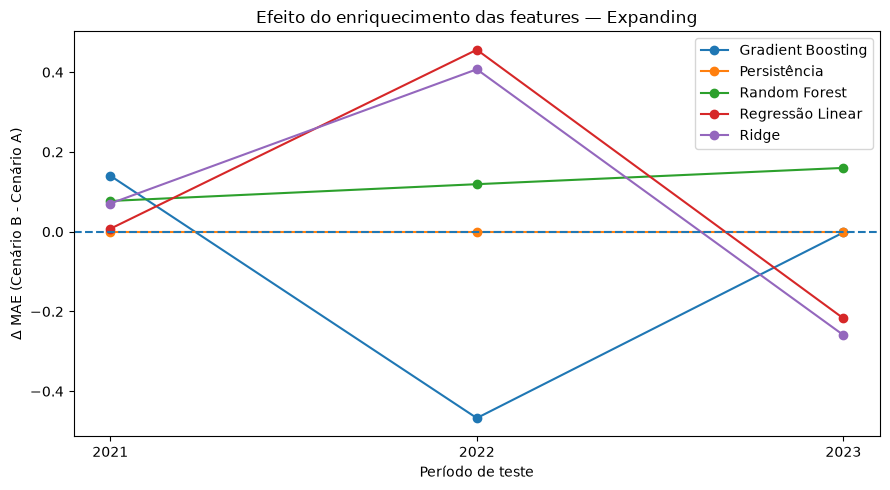

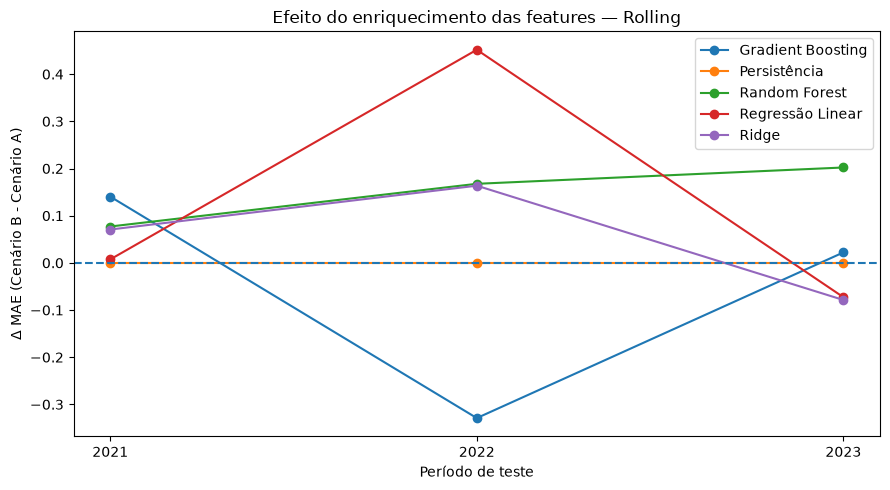

In [47]:
import matplotlib.pyplot as plt

for protocolo in ["Expanding", "Rolling"]:

    dados = comparacao_folds[
        comparacao_folds["protocolo"] == protocolo
    ]

    plt.figure(figsize=(9, 5))

    for modelo in dados["modelo"].unique():

        dados_modelo = dados[
            dados["modelo"] == modelo
        ].sort_values("periodo_teste")

        plt.plot(
            dados_modelo["periodo_teste"].astype(str),
            dados_modelo["delta_MAE"],
            marker="o",
            label=modelo
        )

    plt.axhline(0, linestyle="--")

    plt.xlabel("Período de teste")
    plt.ylabel("Δ MAE (Cenário B - Cenário A)")
    plt.title(
        f"Efeito do enriquecimento das features — {protocolo}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

A inclusão das variáveis desagregadas reduziu o MAE médio do Gradient Boosting nos dois protocolos, mas esse ganho foi concentrado principalmente no período de teste 2022–2023; nos demais períodos, o efeito foi pequeno ou desfavorável.

## 5.7 Exportação das comparações entre cenários

In [48]:
CAMINHO_COMPARACAO_CENARIOS = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "comparacao_cenarios_detalhada.csv"
)

comparacao_por_periodo.to_csv(
    CAMINHO_COMPARACAO_CENARIOS,
    index=False
)

In [49]:
CAMINHO_RESUMO_EFEITO = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resumo_efeito_cenario_b.csv"
)

resumo_efeito_b.to_csv(
    CAMINHO_RESUMO_EFEITO,
    index=False
)